# Semana 2 · Distribuciones y anomalías · Telco
Solución de las actividades de `Semana_02_clase_01.html` y `Semana_02_clase_02.html` sobre el archivo suministrado. Las salidas guardadas se calculan con datos reales. Los módulos se entregan junto al notebook.

Se cubren diagnóstico, log1p, Yeo-Johnson/Box-Cox, escalado, pipeline, IQR, Z-score, Isolation Forest, LOF, inspección y tratamiento con trazabilidad. Las salidas ilustrativas del HTML no se copian como resultados. La selección de columnas y los parámetros se basan en entrenamiento. El EDA global inicial se usa para describir el archivo.

El experimento es didáctico y no entrena un predictor. El split aleatorio sigue el curso; para pronosticar peajes futuros haría falta reservar periodos futuros completos. El acuerdo entre detectores es una señal de revisión, no una etiqueta de verdad.


In [1]:
from pathlib import Path
import sys,json,hashlib
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/data.py').exists())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer,StandardScaler,RobustScaler,MinMaxScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from src.data import NormalizeText,RESUMEN,FEATURES
import joblib
RANDOM_STATE=42
pd.set_option('display.max_columns',40)
(ROOT/'reports').mkdir(exist_ok=True)
(ROOT/'models').mkdir(exist_ok=True)


## Clase 1 · 0. Telco: primera lectura y adaptación
El Excel tiene una hoja `Telco_Churn`, 33 columnas y encabezados distintos a la versión CSV de 21 columnas usada habitualmente. Se usa esta copia real, sin renombrar columnas por suposición. `Total Charges` contiene espacios que se convierten a NaN con una bandera. Los clientes afectados tienen antigüedad cero: es un patrón observado, compatible con un proceso de facturación aún no iniciado, no una prueba del mecanismo MAR.

`Churn Label` es el objetivo. Se excluye `Churn Value` (duplicación de la etiqueta), `Churn Reason` (motivo disponible tras la baja), `Churn Score` (puntuación derivada cuyo origen no se acredita), y `CLTV` hasta verificar cómo/cuándo se calculó. CustomerID es identificador; Zip Code es categoría geográfica, no magnitud. Country, State y Count se revisan como constantes. Latitud y longitud son geográficas: no se transforman como medidas de facturación.

Se analizan tres numéricas de negocio: Tenure Months, Monthly Charges, Total Charges. Se justifica trabajar con tres en la extensión multivariada: no se agregan columnas con fuga para forzar cuatro a seis. La práctica principal de peajes sí usa seis. Se mantienen las categorías `No internet service` y `No phone service`, que tienen significado real.


In [2]:
DATASET='telco'
path=ROOT/'data/raw/Telco_customer_churn.xlsx'
raw=pd.read_excel(path,sheet_name='Telco_Churn')
df=NormalizeText().fit_transform(raw)
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')
df['total_charges_missing']=df['Total Charges'].isna().astype(int)
num_cols=['Tenure Months','Monthly Charges','Total Charges']
cat_cols=['Gender','Senior Citizen','Partner','Dependents','Phone Service','Multiple Lines',
          'Internet Service','Online Security','Online Backup','Device Protection','Tech Support',
          'Streaming TV','Streaming Movies','Contract','Paperless Billing','Payment Method']
temporal_cols=[] # No hay fecha calendario. Tenure Months mide duración.
mult_cols=num_cols.copy();context=['CustomerID','Churn Label','Contract'];focus='Total Charges'
print('Dimensiones:',raw.shape,'Constantes:',raw.columns[raw.nunique(dropna=False).le(1)].tolist())
display(raw.head());raw.info();display(df.describe(include='all').T)
display(df.isna().sum().loc[lambda s:s>0].to_frame('faltantes'))
display(df.loc[df['Total Charges'].isna(),['CustomerID','Tenure Months','Monthly Charges']])
display(pd.crosstab(df['Churn Label'],df['Churn Reason'].isna()))
assert df['Churn Value'].eq(df['Churn Label'].eq('Yes').astype(int)).all()
display(df['Churn Label'].value_counts().to_frame('n'))
display((100*df['Churn Label'].value_counts(normalize=True)).to_frame('porcentaje'))
print('Duplicados de CustomerID:',df['CustomerID'].duplicated().sum())
train,test=train_test_split(df,test_size=.2,random_state=42,stratify=df['Churn Label'])
print('Partición única train/test:',train.shape,test.shape)


Dimensiones: (7043, 33) Constantes: ['Count', 'Country', 'State']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"32.67102, -117.095235",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,faltantes
Total Charges,11
Churn Reason,5174


,CustomerID,Tenure Months,Monthly Charges
2234,4472-LVYGI,0,52.55
2438,3115-CZMZD,0,20.25
2568,5709-LVOEQ,0,80.85
2667,4367-NUYAO,0,25.75
2856,1371-DWPAZ,0,56.05
4331,7644-OMVMY,0,19.85
4687,3213-VVOLG,0,25.35
5104,2520-SGTTA,0,20.00
5719,2923-ARZLG,0,19.70
6772,4075-WKNIU,0,73.35


Churn Reason,False,True
Churn Label,,
No,0,5174
Yes,1869,0


,n
Churn Label,
No,5174
Yes,1869


,porcentaje
Churn Label,
No,73.463013
Yes,26.536987


Duplicados de CustomerID: 0
Partición única train/test: (5634, 34) (1409, 34)


## Complemento de Semana 1 · Imputación medible
Se recuperan cargos totales artificialmente ocultados, usando las tres numéricas de negocio y únicamente train. Es una comparación de recuperación interna, no prueba de rendimiento en los 11 faltantes reales: estos se concentran en antigüedad cero, a diferencia de la máscara aleatoria. El pipeline posterior mantiene mediana como baseline; cambiarla por el ganador requiere evaluar el mecanismo real. El significado «aún sin cargo acumulado» se confirmaría con el diccionario antes de rellenar con cero.


,metodo,n_ocultos,RMSE,MAE,predicciones_negativas
2,KNN estandarizado,843,78.629622,52.605623,0
1,KNN sin escala,843,79.474510,52.828126,0
3,Iterativa estandarizada,843,751.096439,600.674948,132
0,Mediana,843,2441.265791,1784.608482,0


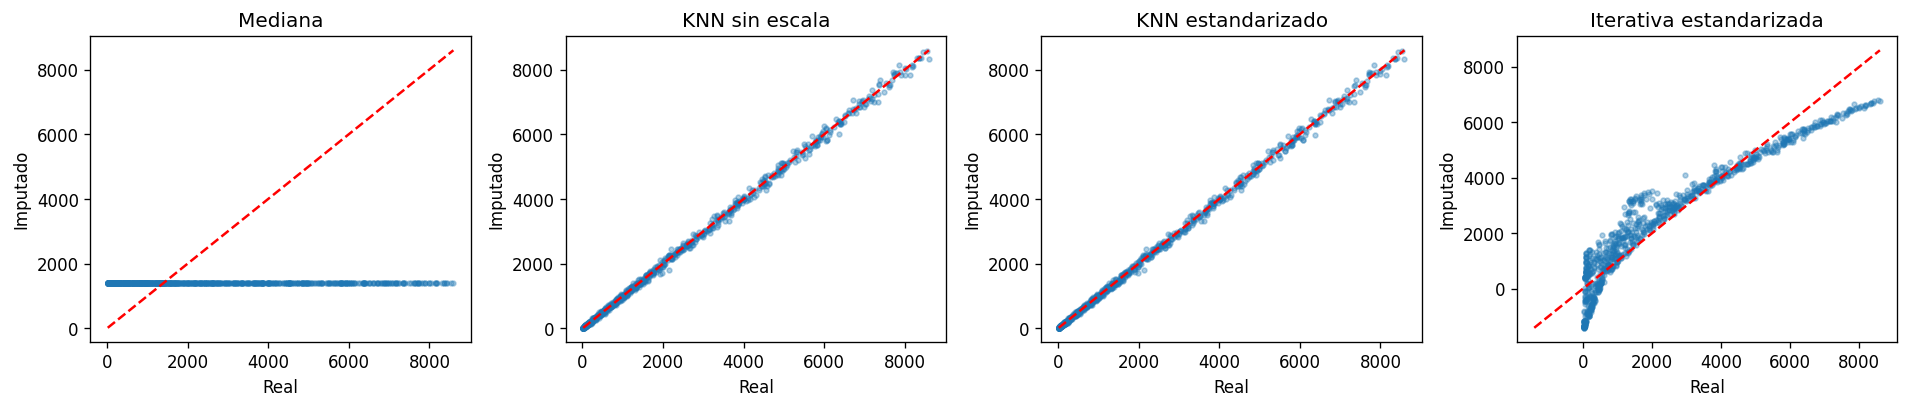

In [3]:
from src.features import compare_imputers
imputation_scores,imputation_truth,imputation_frames=compare_imputers(train[num_cols],'Total Charges')
display(imputation_scores)
fig,axs=plt.subplots(1,4,figsize=(16,3.5))
for ax,(name,frame) in zip(axs,imputation_frames.items()):
    predicted=frame.loc[imputation_truth.index,'Total Charges']
    ax.scatter(imputation_truth,predicted,s=8,alpha=.35)
    low=min(imputation_truth.min(),predicted.min());high=max(imputation_truth.max(),predicted.max())
    ax.plot([low,high],[low,high],'r--');ax.set(title=name,xlabel='Real',ylabel='Imputado')
plt.tight_layout();plt.show()


## Clase 1 · 1–2. Forma: tres razones, skew y curtosis
Se reportan diagnóstico global y diagnóstico de train por separado. La lista de tres variables más sesgadas se decide por **valor absoluto** de skew en train. Si la mediana es cero, máximo/mediana no está definido: no se reemplaza artificialmente por 1. La razón es una señal descriptiva, no una medida universal del peso de la cola.

Los predictores de una regresión no tienen que ser normales. KNN y SVM-RBF dependen de distancias; regresión lineal/logística no son clasificadores por cercanía. La escala puede influir en optimización y regularización. Para árboles supervisados, escala y transformaciones estrictamente crecientes suelen ser innecesarias en predictores, con matices de implementación; esto no implica que los extremos sean siempre inocuos.


GLOBAL


,skew,exceso_curtosis,media,mediana,max
Total Charges,0.961642,-0.231799,2283.300441,1397.475,8684.80
Tenure Months,0.239540,-1.387372,32.371149,29.000,72.00
Monthly Charges,-0.220524,-1.257260,64.761692,70.350,118.75


TRAIN


,skew,exceso_curtosis,media,mediana,max,max_sobre_mediana
Total Charges,0.947516,-0.267494,2302.604266,1398.125,8684.80,6.211748
Tenure Months,0.237369,-1.387347,32.485091,29.000,72.00,2.482759
Monthly Charges,-0.224363,-1.260405,64.929961,70.500,118.75,1.684397


Tres razones máximo/mediana:


,max,mediana,max_sobre_mediana
Total Charges,8684.80,1398.125,6.211748
Tenure Months,72.00,29.000,2.482759
Monthly Charges,118.75,70.500,1.684397


Columnas |skew|>1 (global/train): 0 0
Más sesgada en train: Total Charges


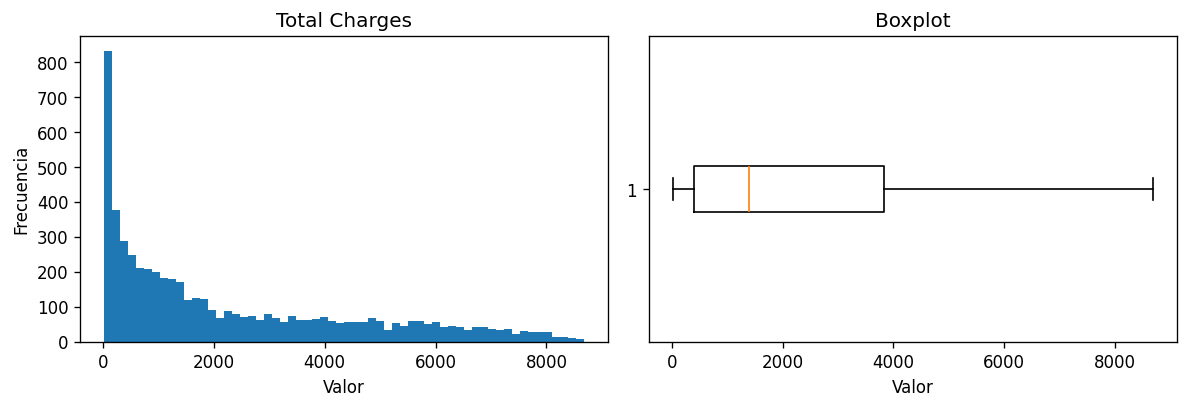

In [4]:
form_global=pd.DataFrame({'skew':df[num_cols].skew(),'exceso_curtosis':df[num_cols].kurt(),
                         'media':df[num_cols].mean(),'mediana':df[num_cols].median(),'max':df[num_cols].max()})
form=pd.DataFrame({'skew':train[num_cols].skew(),'exceso_curtosis':train[num_cols].kurt(),
                  'media':train[num_cols].mean(),'mediana':train[num_cols].median(),'max':train[num_cols].max()})
form['max_sobre_mediana']=form['max']/form['mediana'].replace(0,np.nan)
ordered=form['skew'].abs().sort_values(ascending=False).index.tolist()
top3=ordered[:3];selected=top3[0]
print('GLOBAL');display(form_global.sort_values('skew',ascending=False))
print('TRAIN');display(form.loc[ordered])
print('Tres razones máximo/mediana:');display(form.loc[top3,['max','mediana','max_sobre_mediana']])
print('Columnas |skew|>1 (global/train):',int(form_global['skew'].abs().gt(1).sum()),int(form['skew'].abs().gt(1).sum()))
print('Más sesgada en train:',selected)
x=train[selected].dropna()
fig,axs=plt.subplots(1,2,figsize=(10,3.5))
axs[0].hist(x,bins=60);axs[0].set(title=selected,xlabel='Valor',ylabel='Frecuencia')
axs[1].boxplot(x,vert=False);axs[1].set(title='Boxplot',xlabel='Valor')
plt.tight_layout();plt.show()


## Clase 1 · 3. log1p e inversa
log1p(x)=ln(1+x) está definido en reales para **x > −1**. Por tanto, admite negativos entre −1 y 0. En −1 devuelve −∞; por debajo de −1 produce NaN con NumPy real. No es correcto afirmar que falla para todo negativo.

Se verifica la inversa numéricamente con `allclose`; no se promete igualdad bit a bit. Reducir |skew| no demuestra normalidad ni mejora predictiva. Si el objetivo se transformase, invertir una predicción media en log no recupera automáticamente la media en escala original.


Skew original/log1p: 0.947516259546052 -0.7446564620822211 Inversa: True


,x,log1p
0,-2.0,NaN
1,-1.0,-inf
2,-0.5,-0.693147
3,0.0,0.000000
4,1.0,0.693147


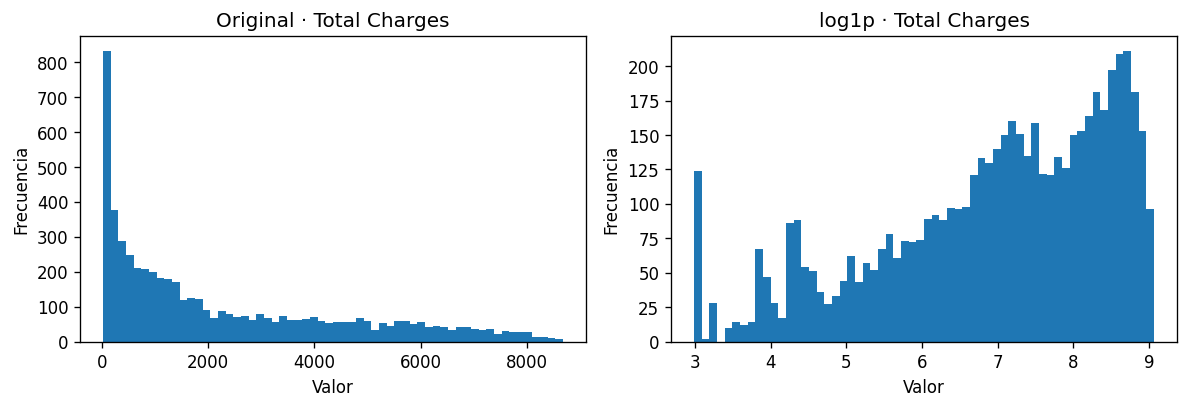

In [5]:
assert (x>=0).all(), 'La selección actual requiere conteos/cargos no negativos.'
logx=np.log1p(x)
inverse_ok=bool(np.allclose(np.expm1(logx),x))
print('Skew original/log1p:',x.skew(),logx.skew(),'Inversa:',inverse_ok)
with np.errstate(divide='ignore',invalid='ignore'):
    display(pd.DataFrame({'x':[-2.,-1.,-.5,0.,1.], 'log1p':np.log1p([-2.,-1.,-.5,0.,1.])}))
fig,axs=plt.subplots(1,2,figsize=(10,3.5))
axs[0].hist(x,bins=60);axs[0].set_title('Original · '+selected)
axs[1].hist(logx,bins=60);axs[1].set_title('log1p · '+selected)
for ax in axs:ax.set(xlabel='Valor',ylabel='Frecuencia')
plt.tight_layout();plt.show()


## Clase 1 · 4. Yeo-Johnson y Box-Cox
El lambda se estima con train observado y se aplica sin reajuste a test observado. Se compara log1p e Yeo-Johnson sobre exactamente las mismas filas de train. Se desactiva `standardize` para separar transformación de forma y escalado posterior.

Box-Cox exige x>0. Si la columna elegida no contiene ceros, la prueba de dominio usa el vector explícito [0,1,2]: es una demostración matemática, no una alteración del dataset. Yeo-Johnson se ajusta por un criterio de verosimilitud bajo normalidad; no minimiza directamente |skew| ni garantiza normalidad.


In [6]:
power=PowerTransformer(method='yeo-johnson',standardize=False)
tr_yj=power.fit_transform(train[[selected]].dropna())
te_yj=power.transform(test[[selected]].dropna())
shape_comparison=pd.DataFrame({'metodo':['Original','log1p','Yeo-Johnson'],
 'skew_train':[x.skew(),logx.skew(),pd.Series(tr_yj.ravel()).skew()]})
shape_comparison['abs_skew']=shape_comparison['skew_train'].abs()
display(shape_comparison)
print('Lambda:',power.lambdas_[0],'Más simétrica de las dos transformaciones:',shape_comparison.iloc[1:].sort_values('abs_skew').iloc[0]['metodo'])
try:
    PowerTransformer(method='box-cox').fit(np.array([[0.],[1.],[2.]]))
except ValueError as err:
    print('Error reproducido con cero:',str(err))
if (x>0).all():
    bc=PowerTransformer(method='box-cox',standardize=False).fit(x.to_numpy().reshape(-1,1))
    print('Box-Cox en esta columna positiva sí funciona; lambda:',bc.lambdas_[0])


,metodo,skew_train,abs_skew
0,Original,0.947516,0.947516
1,log1p,-0.744656,0.744656
2,Yeo-Johnson,-0.145603,0.145603


Lambda: 0.2543477034287946 Más simétrica de las dos transformaciones: Yeo-Johnson
Error reproducido con cero: The Box-Cox transformation can only be applied to strictly positive data
Box-Cox en esta columna positiva sí funciona; lambda: 0.2556391053426232


## Clase 1 · 5. Standard, Robust y MinMax
Los tres se ajustan en train. Se informan centros y escalas de la columna seleccionada. Standard usa desviación poblacional (ddof=0); pandas `std()` usa ddof=1 por defecto. La razón desviación/IQR compara dos medidas distintas: **no cuantifica por sí sola cuánto infló un outlier a la desviación**.

MinMax puede producir valores de test fuera de [0,1] si exceden el rango de train. Robust no elimina outliers. Para una base de distancias con extremos conservados se usa Robust en el detector; después de Yeo-Johnson se usa Standard como ejercicio.


In [7]:
std=StandardScaler().fit(x.to_numpy().reshape(-1,1))
rob=RobustScaler().fit(x.to_numpy().reshape(-1,1))
mm=MinMaxScaler().fit(x.to_numpy().reshape(-1,1))
scale_table=pd.DataFrame({'metodo':['Standard','Robust','MinMax'],
 'centro_o_min':[std.mean_[0],rob.center_[0],mm.data_min_[0]],
 'escala_o_rango':[std.scale_[0],rob.scale_[0],mm.data_range_[0]]})
display(scale_table)
print('Desviación/IQR:',std.scale_[0]/rob.scale_[0])
print('Rango MinMax test:',mm.transform(test[[selected]].dropna()).min(),mm.transform(test[[selected]].dropna()).max())


,metodo,centro_o_min,escala_o_rango
0,Standard,2302.604266,2278.970609
1,Robust,1398.125000,3431.337500
2,MinMax,18.850000,8665.950000


Desviación/IQR: 0.6641639330097608
Rango MinMax test: -5.769707879689848e-06 0.9782943589566062


## Clase 1 · 6. Reto: imputación, forma y escala
El pipeline transforma las numéricas; categorías van por imputación y One-Hot. El objetivo y los identificadores no entran. PowerTransformer usa `standardize=False`: de lo contrario el StandardScaler final sería redundante. Se verifica la salida por columna, sin exigir que todas mejoren: una masa grande de ceros puede persistir tras una transformación monótona.

Para un árbol supervisado generalmente se omitirían PowerTransformer y escalado de predictores. El tratamiento de faltantes/categorías depende del estimador utilizado. No se transforman objetivos en este ejercicio.


In [8]:
pipe_num=Pipeline([('imp',SimpleImputer(strategy='median')),
                   ('power',PowerTransformer(method='yeo-johnson',standardize=False)),
                   ('scale',StandardScaler())])
pipe_cat=Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                  ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
pre=ColumnTransformer([('num',pipe_num,num_cols),('cat',pipe_cat,cat_cols)],remainder='drop')
prepared_train=pre.fit_transform(train)
prepared_test=pre.transform(test)
num_prepared=pd.DataFrame(prepared_train[:,:len(num_cols)],columns=num_cols,index=train.index)
# Compara sobre la misma población imputada, para no atribuir a YJ el efecto de la imputación.
num_imputed=pd.DataFrame(pre.named_transformers_['num'].named_steps['imp'].transform(train[num_cols]),columns=num_cols,index=train.index)
pipeline_shape=pd.DataFrame({'skew_antes_imputado':num_imputed.skew(),'skew_despues':num_prepared.skew()})
pipeline_shape['mejora_abs']=pipeline_shape['skew_despues'].abs()<pipeline_shape['skew_antes_imputado'].abs()
display(pipeline_shape)
print('Shapes:',prepared_train.shape,prepared_test.shape)
assert np.isfinite(prepared_train).all() and np.isfinite(prepared_test).all()
assert prepared_train.shape[1]==prepared_test.shape[1]
joblib.dump(pre,ROOT/f'models/preprocesador_semana2_{DATASET}.joblib')


,skew_antes_imputado,skew_despues,mejora_abs
Tenure Months,0.237369,-0.243509,False
Monthly Charges,-0.224363,-0.260584,False
Total Charges,0.949474,-0.145317,True


Shapes: (5634, 46) (1409, 46)


## Clase 2 · 0–2. IQR en las tres columnas más sesgadas
Las vallas se aprenden en train observado. Se presentan conteos para k=1,5 y k=3,0 en train/test. Los porcentajes usan como denominador las filas observadas de cada columna, no todo el dataset. Los nulos no se clasifican como normales: se mantienen sin evaluar.

Los cuartiles son robustos, no inmunes. IQR=0 hace que cualquier valor distinto al cuartil se marque; en variables con masa en cero puede ser inadecuado interpretar esto como error. Los bigotes de un boxplot llegan a la observación extrema dentro de las vallas, no necesariamente a las vallas mismas. Un símbolo puede superponerse con otros; la cantidad de puntos dibujados se comprueba con sus datos.


,variable,k,split,IQR_train,bajo,alto,evaluados,outliers,pct
0,Total Charges,1.5,train,3431.3375,-4739.73125,8985.61875,5626,0,0.0
1,Total Charges,1.5,test,3431.3375,-4739.73125,8985.61875,1406,0,0.0
2,Total Charges,3.0,train,3431.3375,-9886.73750,14132.62500,5626,0,0.0
3,Total Charges,3.0,test,3431.3375,-9886.73750,14132.62500,1406,0,0.0
4,Tenure Months,1.5,train,46.0000,-60.00000,124.00000,5634,0,0.0
5,Tenure Months,1.5,test,46.0000,-60.00000,124.00000,1409,0,0.0
6,Tenure Months,3.0,train,46.0000,-129.00000,193.00000,5634,0,0.0
7,Tenure Months,3.0,test,46.0000,-129.00000,193.00000,1409,0,0.0
8,Monthly Charges,1.5,train,54.3375,-45.84375,171.50625,5634,0,0.0
9,Monthly Charges,1.5,test,54.3375,-45.84375,171.50625,1409,0,0.0


Puntos en datos del boxplot / IQR: 0 0


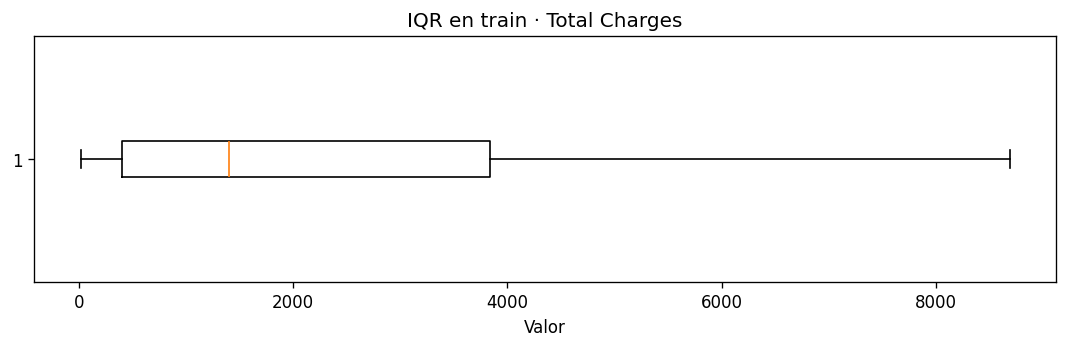

In [9]:
def iqr_limits(s,k=1.5):
    q1,q3=s.dropna().quantile([.25,.75]); spread=q3-q1
    return float(q1-k*spread),float(q3+k*spread),float(spread)
def flags_iqr(s,lo,hi):
    out=pd.Series(pd.NA,index=s.index,dtype='Int64')
    observed=s.notna();out.loc[observed]=(s.loc[observed].lt(lo)|s.loc[observed].gt(hi)).astype(int)
    return out
rows=[]
for c in top3:
    for k in [1.5,3.]:
        lo,hi,spread=iqr_limits(train[c],k)
        for split,frame in [('train',train),('test',test)]:
            flags=flags_iqr(frame[c],lo,hi)
            rows.append({'variable':c,'k':k,'split':split,'IQR_train':spread,'bajo':lo,'alto':hi,
                         'evaluados':int(flags.notna().sum()),'outliers':int(flags.sum()),'pct':float(flags.mean()*100)})
iqr_table=pd.DataFrame(rows);display(iqr_table)
fig,ax=plt.subplots(figsize=(9,3))
bp=ax.boxplot(train[selected].dropna(),vert=False,whis=1.5)
lo,hi,_=iqr_limits(train[selected]);expected=int(flags_iqr(train[selected],lo,hi).sum())
plotted=len(bp['fliers'][0].get_xdata())
print('Puntos en datos del boxplot / IQR:',plotted,expected);assert plotted==expected
ax.set(title='IQR en train · '+selected,xlabel='Valor');plt.tight_layout();plt.show()


## Clase 2 · 3. Z-score e IQR: comprobar la afirmación del HTML
Se trabaja con una columna sesgada fijada (`VEH_TOTAL` en peajes, `Total Charges` en Telco). Media y desviación se estiman en train observado; se aplica el mismo umbral a test. Log cambia la geometría y puede destacar valores muy pequeños. **No hay garantía de que su conteo se acerque al de IQR**.

El Z-score se puede calcular sin normalidad; lo que requiere cuidado es interpretar |z|>3 como una cola excepcional bajo un modelo normal. Sin etiquetas verdaderas de anomalía, «marca menos» no equivale a «subcuenta errores» ni más detecciones equivale a más precisión.


In [10]:
s=train[focus].dropna();lo,hi,_=iqr_limits(s)
mu,sd=s.mean(),s.std(ddof=1)
logs=np.log1p(s);mul,sdl=logs.mean(),logs.std(ddof=1)
zrows=[]
for split,frame in [('train',train),('test',test)]:
    v=frame[focus].dropna()
    counts={'IQR':int(((v<lo)|(v>hi)).sum()),
            'Z crudo':int((((v-mu)/sd).abs()>3).sum()),
            'Z log1p':int((((np.log1p(v)-mul)/sdl).abs()>3).sum())}
    for method,count in counts.items():zrows.append({'split':split,'metodo':method,'n':count,'evaluados':len(v)})
z_table=pd.DataFrame(zrows);display(z_table)
count_tr=z_table.query("split=='train'").set_index('metodo')['n']
print('Distancia al conteo IQR, antes/después:',abs(count_tr['IQR']-count_tr['Z crudo']),abs(count_tr['IQR']-count_tr['Z log1p']))
print('Una diferencia de conteos no mide exactitud; no se fuerza la conclusión del ejemplo.')


,split,metodo,n,evaluados
0,train,IQR,0,5626
1,train,Z crudo,0,5626
2,train,Z log1p,0,5626
3,test,IQR,0,1406
4,test,Z crudo,0,1406
5,test,Z log1p,0,1406


Distancia al conteo IQR, antes/después: 0 0
Una diferencia de conteos no mide exactitud; no se fuerza la conclusión del ejemplo.


## Clase 2 · 4. Isolation Forest
Se emplean conteos de categorías, sin incluir a la vez su total determinista. Se conservan solo casos completos para este detector y se informa cuántos quedaron sin evaluar; no se borran del dataframe original. Es el enfoque didáctico del HTML, con el mismo split de base.

RobustScaler se ajusta con train. El escalado es relevante para LOF; **Isolation Forest estándar no lo requiere por distancias**, y los cambios afines positivos suelen preservar sus particiones aleatorias salvo efectos numéricos. Sí puede cambiar al aplicar transformaciones no lineales. Contamination ajusta el umbral; no descubre la prevalencia verdadera.


In [11]:
A=train[mult_cols].dropna();B=test[mult_cols].dropna()
sc=RobustScaler().fit(A);Atr=sc.transform(A);Bte=sc.transform(B)
print('Features:',mult_cols,'Casos completos train/test:',A.shape,B.shape)
print('Sin evaluar train/test:',len(train)-len(A),len(test)-len(B))
iso_rows=[];isos={}
for contamination in [.01,.05,.10]:
    model=IsolationForest(contamination=contamination,random_state=42,n_estimators=100)
    model.fit(Atr);isos[contamination]=model
    iso_rows.append({'contamination':contamination,'anom_train':int((model.predict(Atr)==-1).sum()),
                    'n_train':len(A),'anom_test':int((model.predict(Bte)==-1).sum()),'n_test':len(B)})
iso_table=pd.DataFrame(iso_rows);display(iso_table)
iso=isos[.05];iso_tr=iso.predict(Atr);iso_te=iso.predict(Bte)
# Más anómalos según score menor; muestra de tres casos en test.
rank=pd.Series(iso.decision_function(Bte),index=B.index).sort_values()
flagged=rank.loc[rank<0].index[:3]
inspection=df.loc[flagged,context+mult_cols].copy()
inspection['score_iso']=rank.loc[flagged]
display(inspection)


Features: ['Tenure Months', 'Monthly Charges', 'Total Charges'] Casos completos train/test: (5626, 3) (1406, 3)
Sin evaluar train/test: 8 3


,contamination,anom_train,n_train,anom_test,n_test
0,0.01,57,5626,17,1406
1,0.05,282,5626,68,1406
2,0.10,563,5626,144,1406


,CustomerID,Churn Label,Contract,Tenure Months,Monthly Charges,Total Charges,score_iso
4973,0017-IUDMW,No,Two year,72,116.80,8456.75,-0.049721
4029,0106-UGRDO,No,Two year,69,116.00,8182.85,-0.047376
6151,3396-DKDEL,No,Two year,70,115.15,8250.00,-0.045589


## Clase 2 · 5. LOF: vecindarios 10, 20 y 35
LOF se ajusta y evalúa en train con `fit_predict`; no se aplica este modo a test. Se usa contamination='auto' para reproducir la lógica por defecto. Cambiar k modifica la referencia local; no garantiza un conteo monótono. Se informa intersección y unión con Isolation Forest de 5 % sobre **las mismas filas de entrenamiento**.

Un caso señalado solo por LOF puede ser raro respecto de sus vecinos y no quedar aislado globalmente. Coincidencia no implica que sea un error. En despliegue, LOF con novelty=True se evalúa sobre observaciones nuevas; no se debe confundir ese uso con fit_predict.


Filas adicionales con mismo perfil numérico: 183
Mayor multiplicidad de un perfil: 9


,k,lof_train,iso_train,ambos,union,jaccard
0,10,116,282,12,386,0.031088
1,20,81,282,19,344,0.055233
2,35,83,282,12,353,0.033994


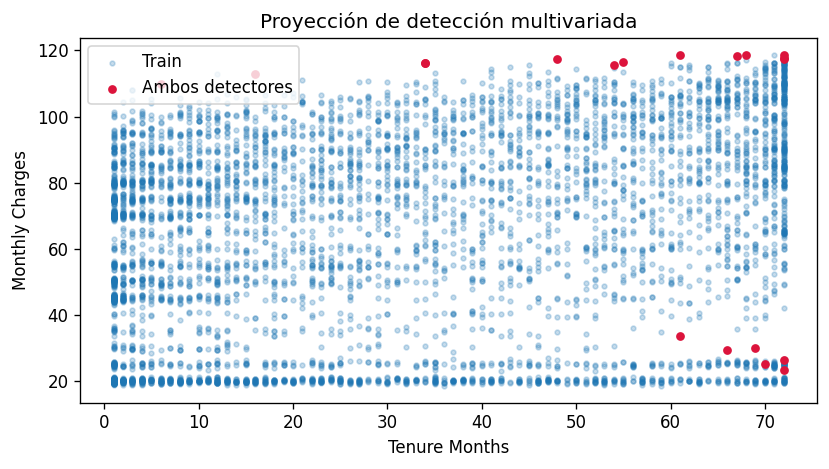

In [12]:
import warnings
lof_rows=[];lof_preds={};lof_warnings=[]
print('Filas adicionales con mismo perfil numérico:',int(A.duplicated().sum()))
print('Mayor multiplicidad de un perfil:',int(A.value_counts().max()))
for k in [10,20,35]:
    with warnings.catch_warnings(record=True) as ws:
        warnings.simplefilter('always')
        pred=LocalOutlierFactor(n_neighbors=k,contamination='auto').fit_predict(Atr)
    lof_warnings.extend([f'k={k}: {w.message}' for w in ws])
    lof_preds[k]=pred
    both=int(((pred==-1)&(iso_tr==-1)).sum())
    union=int(((pred==-1)|(iso_tr==-1)).sum())
    lof_rows.append({'k':k,'lof_train':int((pred==-1).sum()),'iso_train':int((iso_tr==-1).sum()),
                     'ambos':both,'union':union,'jaccard':both/union if union else np.nan})
lof_table=pd.DataFrame(lof_rows);display(lof_table)
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(A.iloc[:,0],A.iloc[:,1],s=8,alpha=.25,label='Train')
both_mask=(lof_preds[20]==-1)&(iso_tr==-1)
ax.scatter(A.loc[both_mask].iloc[:,0],A.loc[both_mask].iloc[:,1],s=18,color='crimson',label='Ambos detectores')
ax.set(xlabel=mult_cols[0],ylabel=mult_cols[1],title='Proyección de detección multivariada')
ax.legend();plt.tight_layout();plt.show()

for message in lof_warnings: print('Advertencia registrada:',message)


### Integración y sensibilidad de los detectores
El ejemplo del HTML aplica RobustScaler a conteos crudos. Esa es la base de los conteos anteriores, para conservar unidades interpretables. Como integración de la Clase 1, se compara también Isolation Forest sobre las mismas seis/tres columnas después de Yeo-Johnson y escalado: la transformación no lineal puede cambiar los cortes y las detecciones. No se elige una variante por producir más anomalías.

Los perfiles repetidos pueden hacer inestable la densidad local de LOF. En peajes se repite el análisis, como sensibilidad, excluyendo del subconjunto de ajuste los totales cero sospechosos. Se reajustan escala, Isolation Forest y LOF en ese subconjunto. No se elimina ninguna fila del dataframe original ni se afirma que las filas excluidas sean errores.


In [13]:
shape_detector=Pipeline([('power',PowerTransformer(method='yeo-johnson',standardize=False)),('scale',StandardScaler())])
shape_A=shape_detector.fit_transform(A);shape_B=shape_detector.transform(B)
iso_shape=IsolationForest(contamination=.05,random_state=42,n_estimators=100).fit(shape_A)
transformed_comparison={'raw_train':int((iso_tr==-1).sum()),'raw_test':int((iso_te==-1).sum()),
 'yj_train':int((iso_shape.predict(shape_A)==-1).sum()),'yj_test':int((iso_shape.predict(shape_B)==-1).sum()),
 'ambos_test':int(((iso_te==-1)&(iso_shape.predict(shape_B)==-1)).sum())}
print('Isolation Forest con forma transformada:',transformed_comparison)
sensitivity=[]
if DATASET=='peajes':
    S=A.loc[train.loc[A.index,'sin_reporte'].eq(0)]
    ssc=RobustScaler().fit(S);SV=ssc.transform(S)
    si=IsolationForest(contamination=.05,random_state=42,n_estimators=100).fit(SV)
    isp=si.predict(SV)
    print('Sensibilidad sin totales cero: filas',len(S),'perfiles adicionales repetidos',int(S.duplicated().sum()))
    for k in [10,20,35]:
        with warnings.catch_warnings(record=True) as ws:
            warnings.simplefilter('always')
            lp=LocalOutlierFactor(n_neighbors=k).fit_predict(SV)
        sensitivity.append({'k':k,'n':len(S),'lof':int((lp==-1).sum()),'iso':int((isp==-1).sum()),
         'ambos':int(((lp==-1)&(isp==-1)).sum()),'advertencias':'; '.join(str(w.message) for w in ws)})
    display(pd.DataFrame(sensitivity))


Isolation Forest con forma transformada: {'raw_train': 282, 'raw_test': 68, 'yj_train': 282, 'yj_test': 74, 'ambos_test': 21}


## Clase 2 · 6. Investigar y tratar sin perder el original
Se inspeccionan las cinco observaciones más altas y el contexto de los casos marcados. Valores altos por sí solos no prueban error ni legitimidad. Se mantiene la clasificación provisional hasta contrastar la fuente.

El tratamiento elegido es **marcar para revisión y conservar**. Se ilustra además una columna capada al p99 de train, conservando la original. Winsorizar modifica información de magnitud, aunque conserve filas: no se adopta automáticamente. Nunca se recorta un objetivo de prueba para mejorar artificialmente una métrica.

Los registros incompletos conservan `NA` en la bandera de Isolation Forest para distinguir «sin evaluar» de «normal». La bandera no debe convertirse en etiqueta de fraude sin validación.


In [14]:
top_values=df.nlargest(5,focus)[context+[focus]]
display(top_values)
trace=df.copy()
trace['es_outlier_iso']=pd.Series(pd.NA,index=df.index,dtype='Int64')
trace.loc[A.index,'es_outlier_iso']=(iso_tr==-1).astype(int)
trace.loc[B.index,'es_outlier_iso']=(iso_te==-1).astype(int)
trace['es_outlier_iqr']=flags_iqr(df[focus],lo,hi)
p99=float(train[focus].quantile(.99))
trace[focus+'_cap_p99']=df[focus].clip(upper=p99)
cap_counts={'train':int(train[focus].gt(p99).sum()),'test':int(test[focus].gt(p99).sum())}
print('p99 aprendido en train:',p99,'Valores capados:',cap_counts)
display(trace['es_outlier_iso'].value_counts(dropna=False).to_frame('n'))
assert trace[focus].equals(df[focus]), 'El original debe conservarse.'
# Trazabilidad guardada sin publicar el dataset completo.
trace.loc[flagged,context+mult_cols+['es_outlier_iso','es_outlier_iqr']].to_json(
    ROOT/f'reports/casos_{DATASET}.json',orient='records',indent=2,force_ascii=False)
joblib.dump({'scaler':sc,'detector':iso,'features':mult_cols,'p99':p99,'iqr':[lo,hi]},ROOT/f'models/detector_{DATASET}.joblib')


,CustomerID,Churn Label,Contract,Total Charges
1206,2889-FPWRM,Yes,One year,8684.80
5251,7569-NMZYQ,No,Two year,8672.45
6850,9739-JLPQJ,No,Two year,8670.10
5814,9788-HNGUT,No,Two year,8594.40
3478,8879-XUAHX,No,Two year,8564.75


p99 aprendido en train: 8040.224999999999 Valores capados: {'train': 57, 'test': 14}


,n
es_outlier_iso,
0,6682
1,350
<NA>,11


**Interpretación de origen:** Total Charges acumula facturación a lo largo de la relación. Valores altos junto con mucha antigüedad y cargos mensuales altos son candidatos a extremos legítimos. No debe imponerse Total Charges = Tenure × Monthly Charges como identidad, porque los cargos pueden variar históricamente. Las combinaciones raras se dejan marcadas para revisar contrato y servicios; no prueban fraude. `Churn Reason` faltante entre clientes que no se fueron es ausencia estructural, no una variable que deba imputarse para predecir la baja.


## Clase 2 · 7. Conclusión del reto
Para una primera herramienta de revisión usaría Isolation Forest como ranking multivariado, junto con verificaciones explícitas de dominio y contexto. LOF aporta contraste local sobre train. Mantendría los registros y una bandera, revisando muestras con expertos antes de fijar un umbral operativo. No elegiría contamination por el número que parezca más cómodo ni afirmaría exactitud sin etiquetas verificadas.

En peajes, la heterogeneidad entre estaciones y la estacionalidad requieren comparar también con el mismo peaje y meses anteriores. En Telco, la finalidad predictiva es churn, y la detección de anomalías no sustituye evaluación de clasificación. Las transformaciones y el tratamiento final se decidirían mediante validación del modelo y su objetivo, no por lograr skew cero.

Todos los conteos de esta entrega son calculados. Cuando una premisa del HTML no se cumple (por ejemplo, que Z log converja al conteo de IQR), se responde con la evidencia en vez de modificar el experimento para forzarla.


In [15]:
summary={'dataset':DATASET,'source_sha256':hashlib.sha256(path.read_bytes()).hexdigest(),
 'rows':len(raw),'cols':len(raw.columns),'train_rows':len(train),'test_rows':len(test),
 'numeric_cols':num_cols,'top3_train':top3,'selected':selected,
 'strong_skew_global':int(form_global['skew'].abs().gt(1).sum()),
 'strong_skew_train':int(form['skew'].abs().gt(1).sum()),
 'lambda':float(power.lambdas_[0]),'inverse_ok':inverse_ok,
 'form_global':form_global.reset_index(names='variable').to_dict('records'),
 'form_train':form.reset_index(names='variable').to_dict('records'),
 'shape_comparison':shape_comparison.to_dict('records'),
 'pipeline_shape':pipeline_shape.reset_index(names='variable').to_dict('records'),
 'pipeline_train_shape':list(prepared_train.shape),'pipeline_test_shape':list(prepared_test.shape),
 'scalers':scale_table.to_dict('records'),'iqr':iqr_table.to_dict('records'),'zscore':z_table.to_dict('records'),
 'isolation':iso_table.to_dict('records'),'lof':lof_table.to_dict('records'),
 'p99':p99,'cap_counts':cap_counts,'top_values':top_values.to_dict('records'),
 'three_anomalies':inspection.to_dict('records')}
if DATASET=='peajes':summary['zero_total']=raw_zero_count
else:summary['total_charges_missing']=int(df['Total Charges'].isna().sum())
summary['lof_warnings']=lof_warnings
summary['lof_sensitivity']=sensitivity
summary['iso_transformed']=transformed_comparison
if DATASET=='telco':summary['imputation']=imputation_scores.to_dict('records')
# pandas serializa los NaN como null, sin emitir JSON no estándar.
pd.Series(summary).to_json(ROOT/f'reports/resultados_{DATASET}.json',force_ascii=False,indent=2)
print('Resultados y modelos guardados. No se borraron filas del dataframe original.')


Resultados y modelos guardados. No se borraron filas del dataframe original.
